In [ ]:
from google.cloud import bigquery
from google.oauth2 import service_account
import db_dtypes

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os

plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False 



credentials = service_account.Credentials.from_service_account_file(
    os.environ["GOOGLE_APPLICATION_CREDENTIALS"]
)
client = bigquery.Client(
    project="myetl-474505",
    credentials=credentials
)

client.query("SELECT 1").to_dataframe()


In [3]:
query=""" 
select *
from `myetl-474505.delivery.food_delivery`
limit 1;
"""

ck=client.query(query).to_dataframe()
ck.info()

/Users/admin/Library/Python/3.9/lib/python/site-packages/google/cloud/bigquery/table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1 entries, 0 to 0
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID                           1 non-null      float64
 1   Delivery_person_ID           1 non-null      object 
 2   Delivery_person_Age          1 non-null      float64
 3   Delivery_person_Ratings      1 non-null      float64
 4   Restaurant_latitude          1 non-null      float64
 5   Restaurant_longitude         1 non-null      float64
 6   Delivery_location_latitude   1 non-null      float64
 7   Delivery_location_longitude  1 non-null      float64
 8   Order_Date                   1 non-null      dbdate 
 9   Time_Orderd                  1 non-null      object 
 10  Time_Order_picked            1 non-null      dbtime 
 11  Weatherconditions            1 non-null      object 
 12  Road_traffic_density         1 non-null      object 
 13  Vehicle_condition       

In [4]:
query=""" 
CREATE OR REPLACE TABLE `myetl-474505.delivery.food_delivery_pre` AS
SELECT
  SAFE_CAST(ID AS INT64) AS id,
  Delivery_person_ID,
  SAFE_CAST(Delivery_person_Age AS INT64) AS delivery_person_age,
  SAFE_CAST(Delivery_person_Ratings AS FLOAT64) AS delivery_person_ratings,

  Restaurant_latitude,
  Restaurant_longitude,
  Delivery_location_latitude,
  Delivery_location_longitude,

  Order_Date,
  TRIM(Time_Orderd) AS time_orderd,
  Time_Order_picked,

  TIMESTAMP(
    DATETIME(
      Order_Date,
      COALESCE(
        SAFE.PARSE_TIME('%H:%M:%S', TRIM(Time_Orderd)),
        SAFE.PARSE_TIME('%H:%M', TRIM(Time_Orderd))
      )
    )
  ) AS order_ts,

  TIMESTAMP(
    DATETIME(Order_Date, Time_Order_picked)
  ) AS picked_ts,

  TIMESTAMP_DIFF(
    TIMESTAMP(DATETIME(Order_Date, Time_Order_picked)),
    TIMESTAMP(
      DATETIME(
        Order_Date,
        COALESCE(
          SAFE.PARSE_TIME('%H:%M:%S', TRIM(Time_Orderd)),
          SAFE.PARSE_TIME('%H:%M', TRIM(Time_Orderd))
        )
      )
    ),
    MINUTE
  ) AS wait_minutes,

  TRIM(Weatherconditions) AS weatherconditions,
  TRIM(Road_traffic_density) AS road_traffic_density,
  Vehicle_condition,
  TRIM(Type_of_order) AS type_of_order,
  TRIM(Type_of_vehicle) AS type_of_vehicle,
  SAFE_CAST(multiple_deliveries AS INT64) AS multiple_deliveries,
  TRIM(Festival) AS festival,
  TRIM(City) AS city,
  SAFE_CAST(REGEXP_EXTRACT(Time_taken_min, r'(\d+)') AS INT64) AS time_taken_min

FROM `myetl-474505.delivery.food_delivery`
WHERE Time_Orderd IS NOT NULL
  AND Time_Order_picked IS NOT NULL;
"""
ck=client.query(query)
ck

QueryJob<project=myetl-474505, location=US, id=2ba6b3a3-57b7-4dbe-9e04-ecc2a4e06cec>

In [5]:
query=""" 
select *
from `myetl-474505.delivery.food_delivery_pre`
limit 1
"""

ck=client.query(query).to_dataframe()
ck

/Users/admin/Library/Python/3.9/lib/python/site-packages/google/cloud/bigquery/table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,id,Delivery_person_ID,delivery_person_age,delivery_person_ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,time_orderd,...,wait_minutes,weatherconditions,road_traffic_density,Vehicle_condition,type_of_order,type_of_vehicle,multiple_deliveries,festival,city,time_taken_min
0,53461,AGRRES010DEL01,<NA>,NaN,27.163303,78.057044,27.173303,78.067044,2022-02-13,NaN,...,<NA>,conditions Sandstorms,Low,2,Drinks,scooter,0,No,Metropolitian,27


In [6]:
#위경도 확인
query=""" 
SELECT count(*)
FROM `myetl-474505.delivery.food_delivery_pre`
WHERE Restaurant_latitude NOT BETWEEN -90 AND 90
   OR Restaurant_longitude NOT BETWEEN -180 AND 180;
"""

ck=client.query(query).to_dataframe()
ck

/Users/admin/Library/Python/3.9/lib/python/site-packages/google/cloud/bigquery/table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,f0_
0,0


In [28]:
#시간 확인
query="""
SELECT
  COUNT(*) AS total_rows,

  COUNTIF(wait_minutes < 0) AS negative_wait,
  ROUND(COUNTIF(wait_minutes < 0) / COUNT(*) * 100, 2) AS negative_wait_pct,

  COUNTIF(wait_minutes > time_taken_min) AS impossible_wait,
  ROUND(COUNTIF(wait_minutes > time_taken_min) / COUNT(*) * 100, 2) AS impossible_wait_pct,


FROM `myetl-474505.delivery.food_delivery_pre`;
""" 

ck=client.query(query).to_dataframe()
ck

/Users/admin/Library/Python/3.9/lib/python/site-packages/google/cloud/bigquery/table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,total_rows,negative_wait,negative_wait_pct,impossible_wait,impossible_wait_pct
0,45593,831,1.82,1175,2.58


어떤 조건에서 픽업 지연이 발생하는지

In [8]:
#time_taken_min (접수~완료), 30 / 이상치 제거 
query=""" 
CREATE OR REPLACE TABLE `myetl-474505.delivery.food_delivery_pre2` AS
SELECT *
FROM `myetl-474505.delivery.food_delivery_pre`
WHERE wait_minutes >= 0
  AND wait_minutes <= time_taken_min
  AND time_taken_min > 0;
"""

ck_clean=client.query(query)
ck_clean

QueryJob<project=myetl-474505, location=US, id=c70028ae-a958-47b7-a2bd-b9a4f3e3040f>

In [9]:
query = """
SELECT
  EXTRACT(HOUR FROM order_ts) AS order_hour,
  COUNT(*) AS order_count,
  AVG(time_taken_min) AS avg_time
FROM `myetl-474505.delivery.food_delivery_pre2`
WHERE wait_minutes >= 0
  AND wait_minutes <= time_taken_min
  AND time_taken_min > 0
GROUP BY order_hour
ORDER BY order_hour;
"""
ck = client.query(query).to_dataframe()
ck

/Users/admin/Library/Python/3.9/lib/python/site-packages/google/cloud/bigquery/table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,order_hour,order_count,avg_time
0,0,410,22.695122
1,8,1693,20.158299
2,9,1816,20.085352
3,10,1875,19.949333
4,11,1901,26.841136
5,12,865,27.297110
6,13,773,27.760673
7,14,781,27.725992
8,15,846,23.554374
9,16,689,23.272859


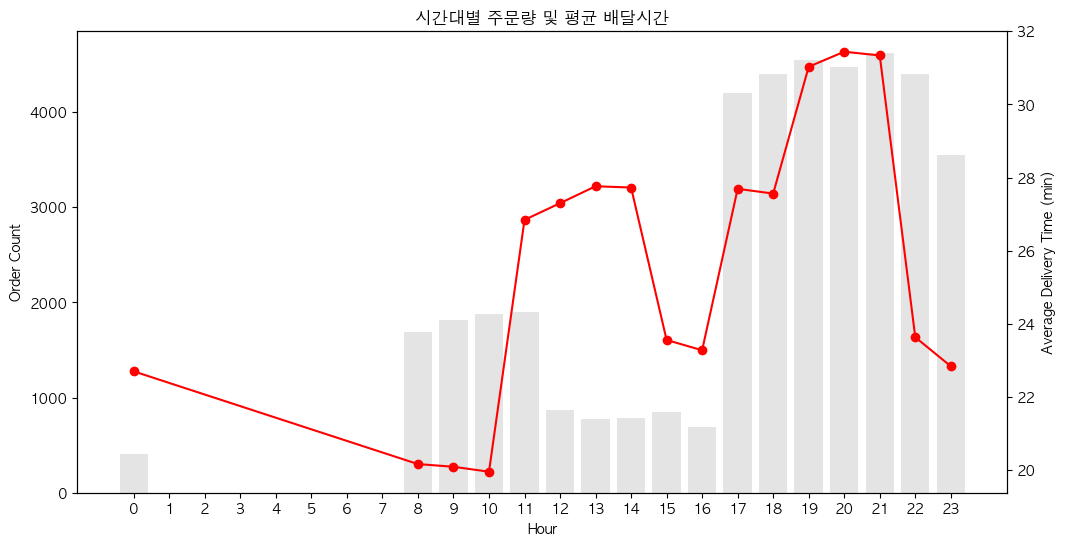

In [10]:
import matplotlib.pyplot as plt

df = ck

fig, ax1 = plt.subplots(figsize=(12,6))

#배달 수
ax1.bar(df['order_hour'], df['order_count'], 
        color='lightgray', alpha=0.6, label='Order Count')
ax1.set_xlabel('Hour')
ax1.set_ylabel('Order Count')
ax1.set_xticks(range(0,24))

#배달 시간
ax2 = ax1.twinx()
ax2.plot(df['order_hour'], df['avg_time'], 
         color='red', marker='o', label='Avg Time')
ax2.set_ylabel('Average Delivery Time (min)')

plt.title('시간대별 주문량 및 평균 배달시간')
plt.show()

11 ~16시 사이 주문량 대비 평균 배달시간이 높게 나왔다

/Users/admin/Library/Python/3.9/lib/python/site-packages/google/cloud/bigquery/table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


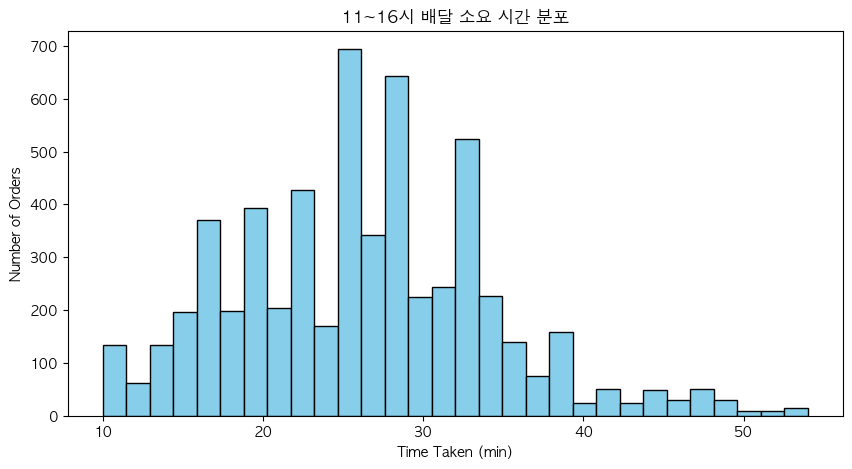

평균: 26.253116994022204
중앙값: 26.0
최소: 10
최대: 54
25~75% 구간: 0.25    20.0
0.75    31.0
Name: time_taken_min, dtype: Float64


In [ ]:
query=""" 
SELECT
  EXTRACT(HOUR FROM order_ts) AS order_hour,
  time_taken_min
FROM `myetl-474505.delivery.food_delivery_pre2`
WHERE EXTRACT(HOUR FROM order_ts) BETWEEN 11 AND 16
"""
ck=client.query(query).to_dataframe()
ck



plt.figure(figsize=(10,5))
plt.hist(ck['time_taken_min'], bins=30, color='skyblue', edgecolor='black')
plt.xlabel('Time Taken (min)')
plt.ylabel('Number of Orders')
plt.title('11~16시 배달 소요 시간 분포')
plt.show()


df = ck['time_taken_min']
print("평균:", df.mean())
print("중앙값:", df.median())
print("최소:", df.min())
print("최대:", df.max())
print("25~75% 구간:", df.quantile([0.25, 0.75]))

In [12]:
query=""" 
select *,
 EXTRACT(HOUR FROM order_ts) AS order_hour,
FROM `myetl-474505.delivery.food_delivery_pre2`
"""
ck_31=client.query(query).to_dataframe()
ck_31

/Users/admin/Library/Python/3.9/lib/python/site-packages/google/cloud/bigquery/table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,id,Delivery_person_ID,delivery_person_age,delivery_person_ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,time_orderd,...,weatherconditions,road_traffic_density,Vehicle_condition,type_of_order,type_of_vehicle,multiple_deliveries,festival,city,time_taken_min,order_hour
0,53236,AGRRES010DEL01,38,5.0,27.163303,78.057044,27.173303,78.067044,2022-02-17,12:00:00,...,conditions Sunny,High,0,Meal,motorcycle,1,No,Metropolitian,23,12
1,57554,AGRRES010DEL01,25,5.0,27.163303,78.057044,27.173303,78.067044,2022-02-15,09:15:00,...,conditions Windy,Low,1,Meal,scooter,0,No,Metropolitian,19,9
2,55970,AGRRES010DEL01,34,4.5,27.163303,78.057044,27.173303,78.067044,2022-02-11,08:25:00,...,conditions Fog,Low,0,Meal,motorcycle,0,No,Metropolitian,23,8
3,50156,AGRRES010DEL01,25,4.8,27.163303,78.057044,27.203303,78.097044,2022-02-17,14:15:00,...,conditions Stormy,High,0,Buffet,motorcycle,0,No,Urban,28,14
4,50575,AGRRES010DEL01,34,4.6,27.163303,78.057044,27.203303,78.097044,2022-02-13,16:30:00,...,conditions Cloudy,Medium,2,Buffet,electric_scooter,1,No,Metropolitian,18,16
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41851,28611,VADRES20DEL03,24,4.8,22.311358,73.164798,22.401358,73.254798,2022-04-02,19:10:00,...,conditions Stormy,Jam,2,Snack,motorcycle,1,No,Metropolitian,28,19
41852,27709,VADRES20DEL03,25,4.9,22.311358,73.164798,22.401358,73.254798,2022-03-06,23:20:00,...,conditions Cloudy,Low,0,Drinks,motorcycle,1,No,Metropolitian,21,23
41853,39086,VADRES20DEL03,30,4.6,22.311358,73.164798,22.401358,73.254798,2022-03-31,22:55:00,...,conditions Stormy,Low,2,Buffet,scooter,1,No,Urban,26,22
41854,29207,VADRES20DEL03,26,5.0,22.311358,73.164798,22.401358,73.254798,2022-03-20,20:15:00,...,conditions Cloudy,Jam,0,Buffet,motorcycle,2,No,Metropolitian,37,20


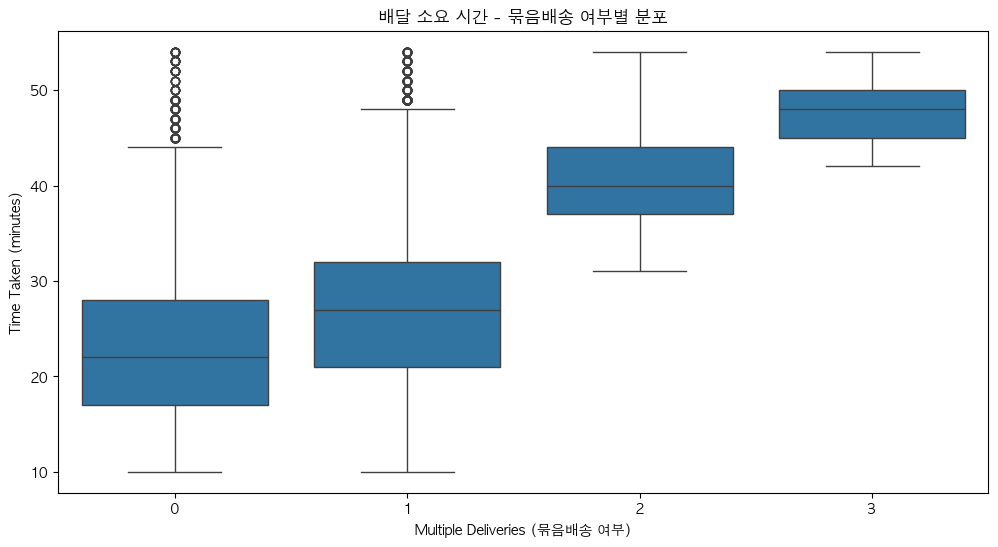

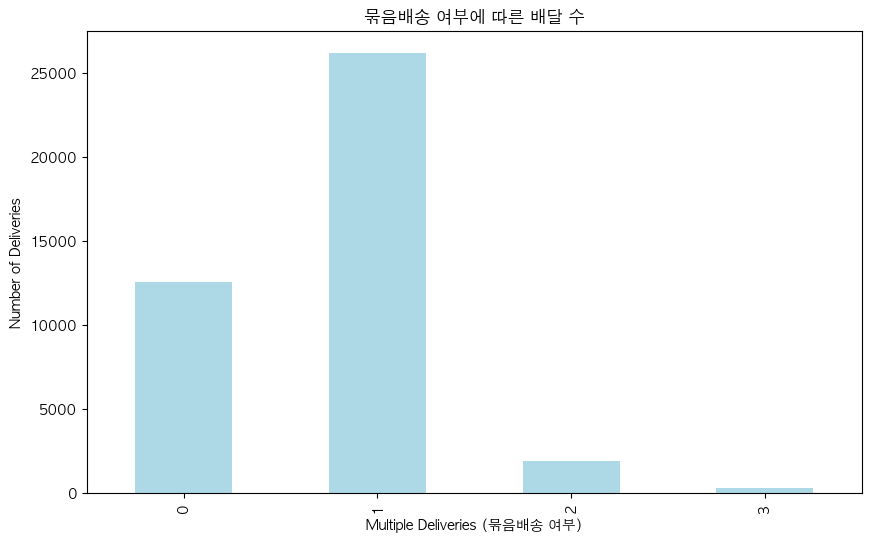

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# 묶음배송 여부에 따른 배달 시간 분포
plt.figure(figsize=(12, 6))
sns.boxplot(x='multiple_deliveries', y='time_taken_min', data=ck_31)
plt.title('배달 소요 시간 - 묶음배송 여부별 분포')
plt.xlabel('Multiple Deliveries (묶음배송 여부)')
plt.ylabel('Time Taken (minutes)')
plt.show()

# 묶음배송 여부에 따른 배달 수
delivery_count = ck_31.groupby('multiple_deliveries')['time_taken_min'].count()

plt.figure(figsize=(10, 6))
delivery_count.plot(kind='bar', color='lightblue')
plt.title('묶음배송 여부에 따른 배달 수')
plt.xlabel('Multiple Deliveries (묶음배송 여부)')
plt.ylabel('Number of Deliveries')
plt.show()

주문량이 많은 시간대(저녁)에 왜 배송 시간이 증가했는가

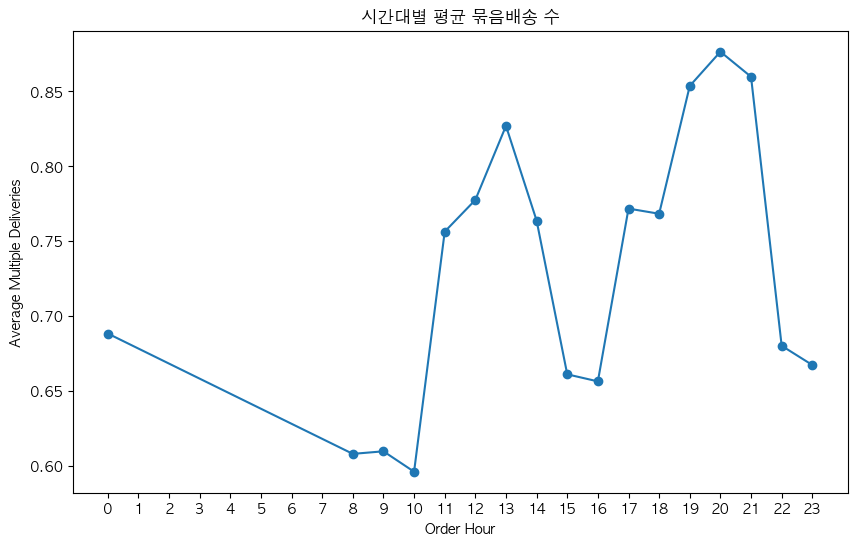

In [14]:
bundle_by_hour = ck_31.groupby('order_hour')['multiple_deliveries'].mean()

plt.figure(figsize=(10,6))
bundle_by_hour.plot(kind='line', marker='o')
plt.title('시간대별 평균 묶음배송 수')
plt.xlabel('Order Hour')
plt.ylabel('Average Multiple Deliveries')
plt.xticks(range(24))

plt.show()


점심시간대는 묶음배송이 높은거에 비해 평균 배달 시간 증가량이 낮았고, 

저녁시간대에는 묶음 배송이 높은거와 비슷하게 평균 배달 시간 증가량이 높았다

In [36]:
def time_group(hour):
    if 11 <= hour <= 14:
        return "lunch"
    elif 18 <= hour <= 21:
        return "dinner"
    else:
        return "other"

ck_31['time_group'] = ck_31['order_hour'].apply(time_group)

pd.crosstab(
    ck_31['time_group'],
    ck_31['road_traffic_density']
)

road_traffic_density,High,Jam,Low,Medium
time_group,,,,
dinner,0,13231,0,4817
lunch,4142,0,178,0
other,84,399,13354,5651


<Axes: xlabel='time_group', ylabel='time_taken_min'>

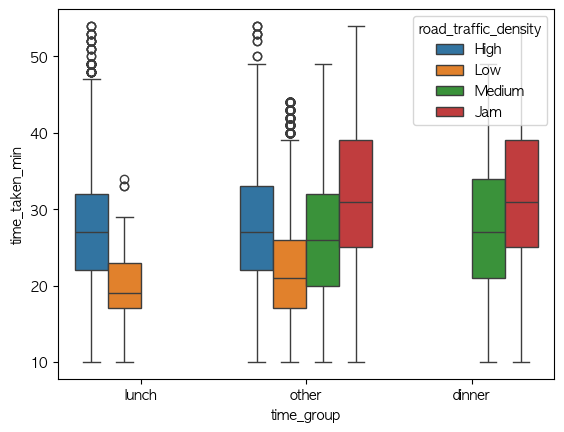

In [35]:
sns.boxplot(
    x='time_group',
    y='time_taken_min',
    hue='road_traffic_density',
    data=ck_31
)